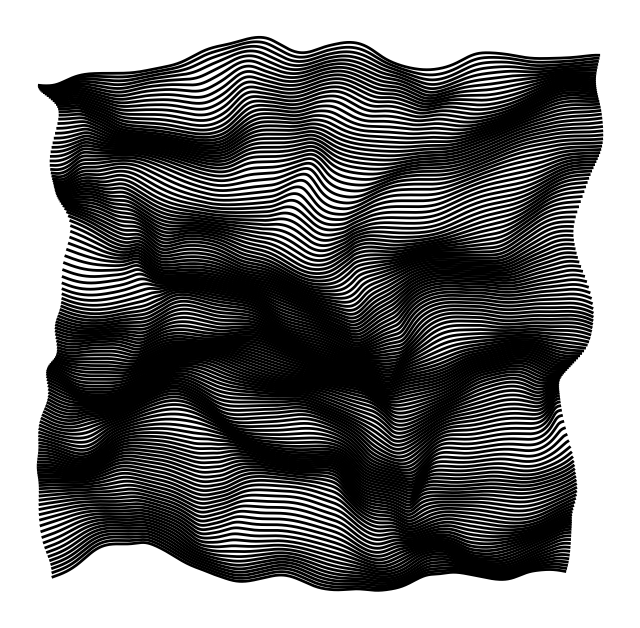

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from noise import pnoise2

width = 1200
height = 1200

line_spacing = 8
points_per_line = 800
linewidth = 2

warp_scale = 0.002
warp_strength = 120

detail_scale = 0.01
detail_strength = 0

seed = 3


def noise(x, y):
    return pnoise2(x, y, octaves=3, base=seed)


def domain_warp(x, y):
    u = x + warp_strength * noise(x * warp_scale, y * warp_scale)
    v = y + warp_strength * noise((x + 1000) * warp_scale, (y + 1000) * warp_scale)

    return u, v


def detail_warp(x, y):
    dx = detail_strength * noise(x * detail_scale, y * detail_scale)
    dy = detail_strength * noise((x + 2000) * detail_scale, (y + 2000) * detail_scale)

    return x + dx, y + dy


lines = []

for y0 in np.arange(0, height, line_spacing):

    xs = np.linspace(0, width, points_per_line)
    ys = np.full_like(xs, y0)

    x_out = []
    y_out = []

    for x, y in zip(xs, ys):
        x1, y1 = domain_warp(x, y)
        x2, y2 = domain_warp(x1, y1)
        x3, y3 = detail_warp(x2, y2)

        x_out.append(x3)
        y_out.append(y3)

    lines.append((x_out, y_out))


plt.figure(figsize=(8,8))

for x, y in lines:
    plt.plot(x, y, color="black", linewidth=linewidth)

plt.gca().set_aspect("equal")
plt.axis("off")

plt.show()